In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRED_DIR = "../outputs/models/predictions/"
PLOT_DIR = "../outputs/models/plots/comparisons/"
os.makedirs(PLOT_DIR, exist_ok=True)

MODELS = {
    "LR": "lr",
    "RF": "rf",
    "LSTM": "lstm",
    "GRU": "gru",
    "CNN-LSTM": "cnn_lstm",
    "Transformer": "transformer",
    "GNN": "gnn",
}

sns.set_style("whitegrid")


def load_preds(model_key, metric, split="test"):
    path = os.path.join(
        PRED_DIR, f"{model_key}_{metric}_{split}_predictions.csv"
    )
    df = pd.read_csv(path)
    return df["y_true"], df["y_pred"]


def plot_model_comparison_pred_vs_actual(
    metric,
    split="test",
    showImage=False
):
    plt.figure(figsize=(8, 8))

    all_true = []
    all_pred = []

    # Plot each model
    for name, key in MODELS.items():
        y_true, y_pred = load_preds(key, metric, split)

        sns.scatterplot(
            x=y_true,
            y=y_pred,
            alpha=0.55,
            label=name,
            s=40
        )

        all_true.append(y_true)
        all_pred.append(y_pred)

    # Global diagonal
    y_min = min([s.min() for s in all_true + all_pred])
    y_max = max([s.max() for s in all_true + all_pred])

    plt.plot(
        [y_min, y_max],
        [y_min, y_max],
        "k--",
        linewidth=2,
        label="Ideal"
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{metric} – Predicted vs Actual (Model Comparison, {split.capitalize()})")
    plt.legend()
    plt.tight_layout()

    out = os.path.join(
        PLOT_DIR, f"compare_{metric.lower()}_{split}_pred_vs_actual.png"
    )
    plt.savefig(out, dpi=300)
    print(f"Saved → {out}")

    if showImage:
        plt.show()
    else:
        plt.close()


Saved → ../outputs/models/plots/comparisons/compare_throughput_test_pred_vs_actual.png


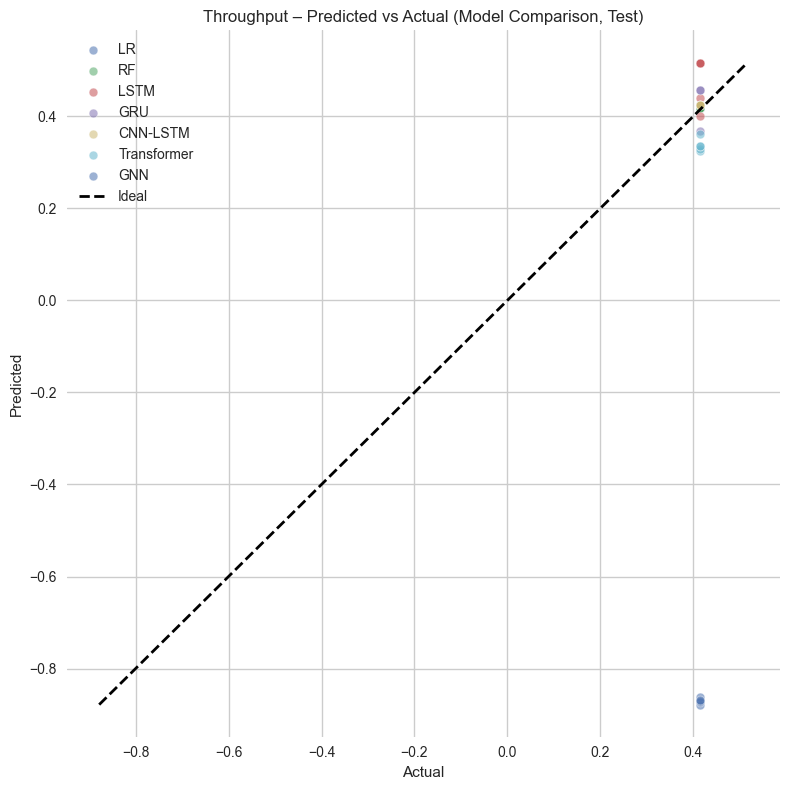

In [22]:
plot_model_comparison_pred_vs_actual(
    metric="Throughput",
    split="test",
    showImage=True
)

Saved → ../outputs/models/plots/comparisons/compare_latency_test_pred_vs_actual.png


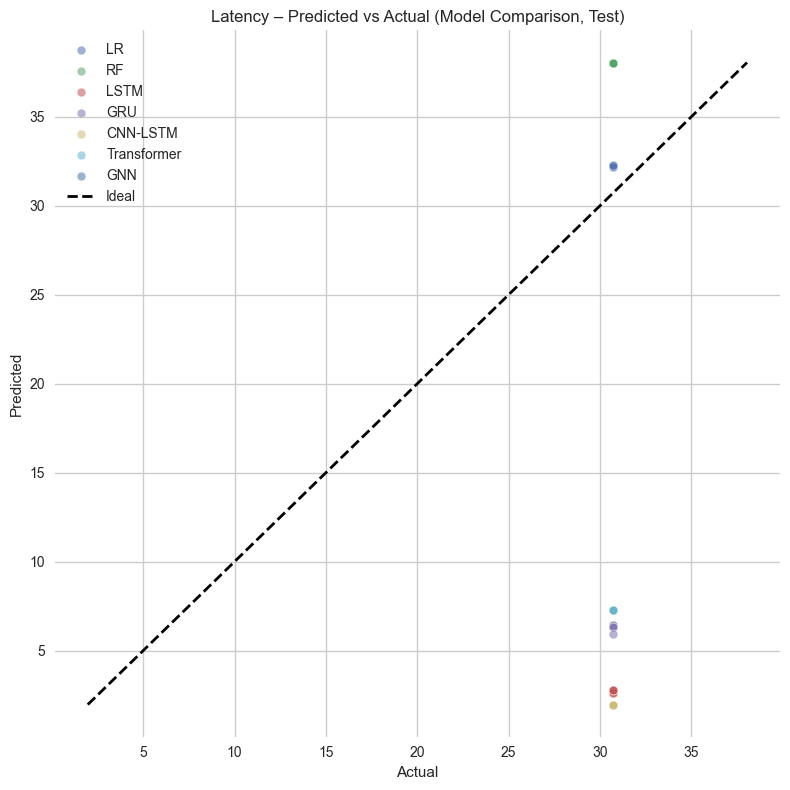

In [24]:
plot_model_comparison_pred_vs_actual(
    metric="Latency",
    split="test",
    showImage=True
)

Saved → ../outputs/models/plots/comparisons/compare_loss_test_pred_vs_actual.png


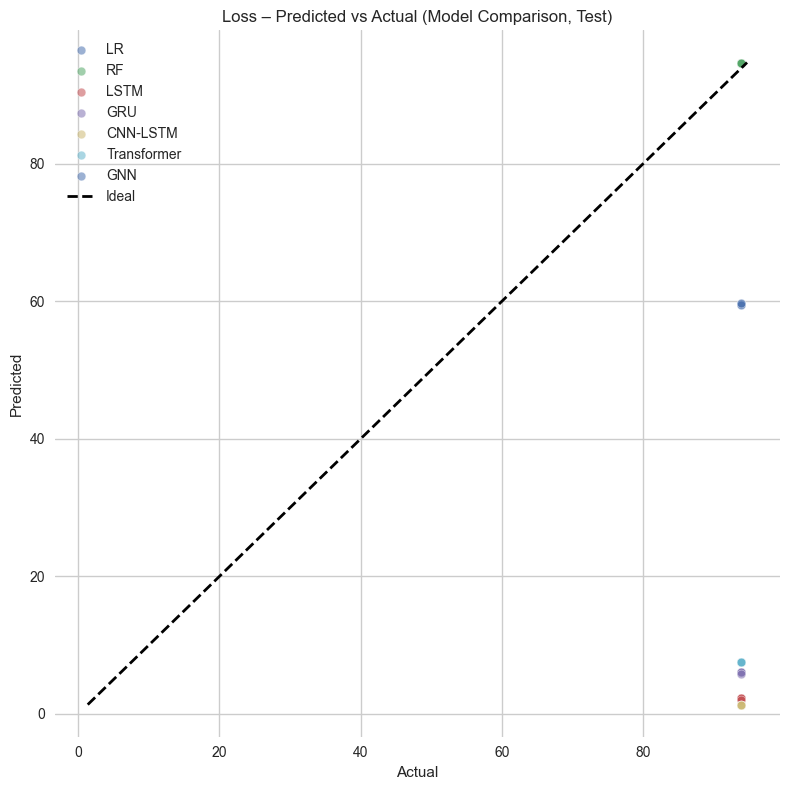

In [25]:
plot_model_comparison_pred_vs_actual(
    metric="Loss",
    split="test",
    showImage=True
)

In [34]:
import os
import pandas as pd
import matplotlib.pyplot as plt

PRED_DIR = "../outputs/models/predictions/"
PLOT_DIR = "../outputs/models/plots/comparisons/"
os.makedirs(PLOT_DIR, exist_ok=True)

# Model → (file_key, color, linestyle)
MODELS = {
    "LR":          ("lr",          "#1f77b4", ":"),    # blue, dotted
    "RF":          ("rf",          "#ff7f0e", "-."),   # orange, dash-dot
    "LSTM":        ("lstm",        "#2ca02c", "--"),   # green, dashed
    "GRU":         ("gru",         "#d62728", "--"),   # red, dashed
    "CNN-LSTM":    ("cnn_lstm",    "#9467bd", "-"),    # purple, solid
    "Transformer": ("transformer", "#8c564b", (0, (5, 2))),  # brown, long-dash
    "GNN":         ("gnn",         "#e377c2", (0, (3, 1, 1, 1))),  # pink, custom
}

plt.style.use("seaborn-v0_8-whitegrid")


def load_preds(model_key, metric, split="test"):
    path = os.path.join(
        PRED_DIR, f"{model_key}_{metric}_{split}_predictions.csv"
    )
    df = pd.read_csv(path)
    return df["y_true"], df["y_pred"]


def plot_model_comparison_time_series(
    metric,
    split="test",
    max_points=300,
    showImage=False
):
    plt.figure(figsize=(13, 6))

    # -------------------------------------------------
    # Ground truth
    # -------------------------------------------------
    first_key = next(iter(MODELS.values()))[0]
    y_true, _ = load_preds(first_key, metric, split)
    y_true = y_true.iloc[:max_points]

    plt.plot(
        y_true.values,
        label="Actual",
        color="black",
        linewidth=3.5,
        linestyle="-"
    )

    # -------------------------------------------------
    # Model predictions
    # -------------------------------------------------
    for model_name, (key, color, style) in MODELS.items():
        _, y_pred = load_preds(key, metric, split)
        y_pred = y_pred.iloc[:max_points]

        plt.plot(
            y_pred.values,
            label=model_name,
            color=color,
            linestyle=style,
            linewidth=2
        )

    plt.title(
        f"{metric} – Time Series Comparison ({split.capitalize()})",
        fontsize=13
    )
    plt.xlabel("Time Index")
    plt.ylabel(metric)

    # -------------------------------------------------
    # Legend BELOW the plot
    # -------------------------------------------------
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=4,
        frameon=True,
        fontsize=9
    )

    # Extra bottom space for legend
    plt.tight_layout(rect=[0, 0.08, 1, 1])

    out = os.path.join(
        PLOT_DIR,
        f"compare_{metric.lower()}_{split}_time_series.png"
    )
    plt.savefig(out, dpi=300)
    print(f"Saved → {out}")

    if showImage:
        plt.show()
    else:
        plt.close()


Saved → ../outputs/models/plots/comparisons/compare_throughput_test_time_series.png


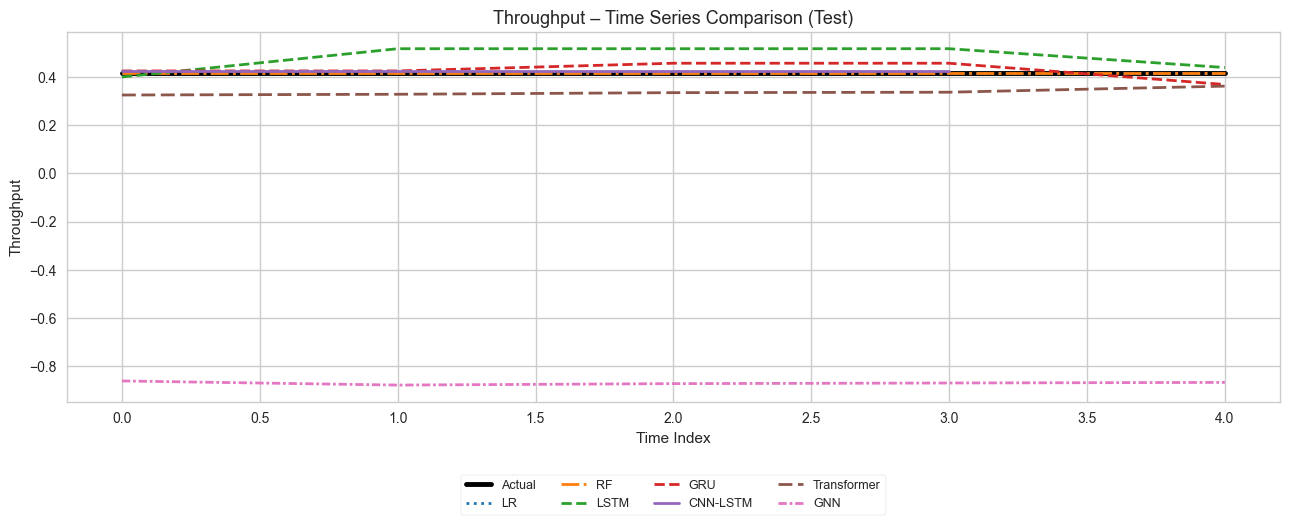

In [35]:
plot_model_comparison_time_series(
    metric="Throughput",
    split="test",
    max_points=300,
    showImage=True
)

Saved → ../outputs/models/plots/comparisons/compare_latency_test_time_series.png


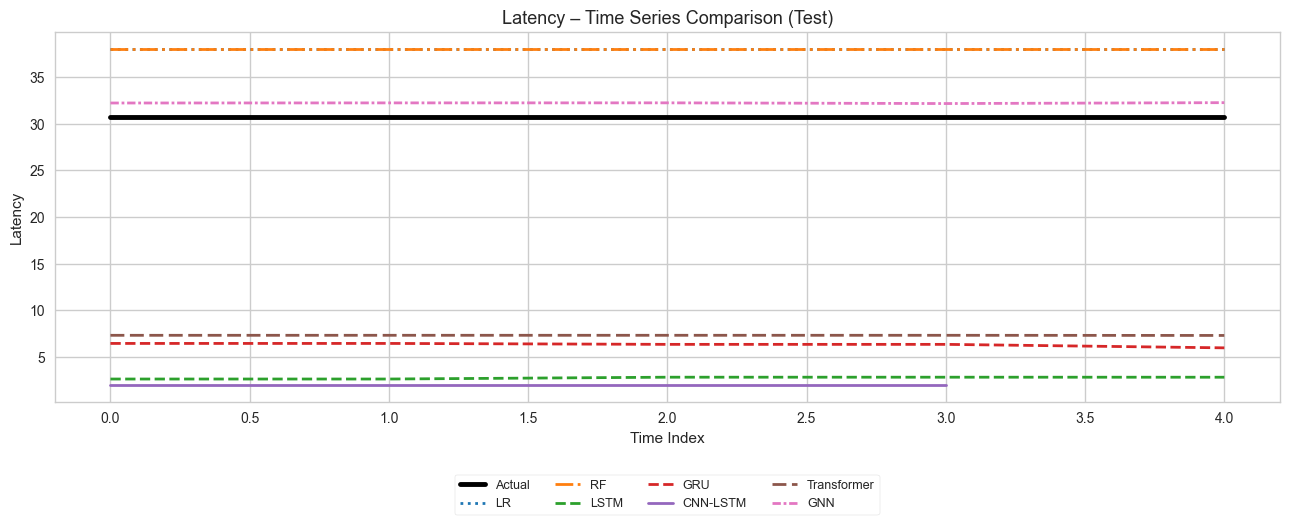

In [36]:
plot_model_comparison_time_series(
    metric="Latency",
    split="test",
    showImage=True
)

Saved → ../outputs/models/plots/comparisons/compare_loss_test_time_series.png


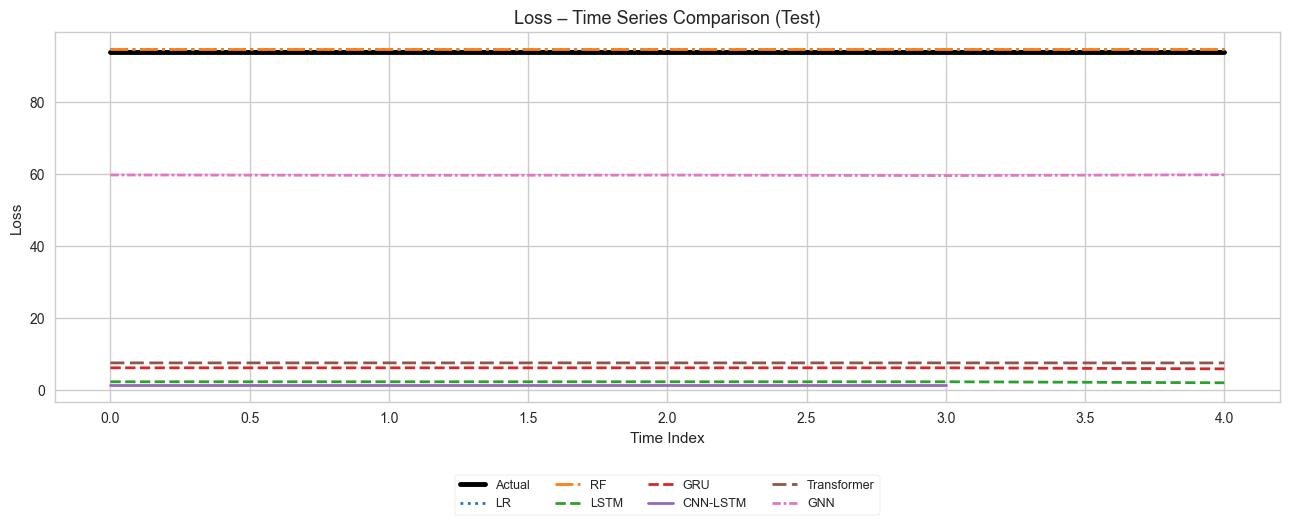

In [37]:
plot_model_comparison_time_series(
    metric="Loss",
    split="test",
    showImage=True
)

In [38]:
import os
import pandas as pd


from edge_evaluations.lr_edge_evaluation import evaluate_lr_edge
from edge_evaluations.rf_edge_evalutaion import  evaluate_rf_edge
from edge_evaluations.xgb_edge_evaluation import evaluate_xgb_edge
from edge_evaluations.mlp_edge_evaluation import evaluate_mlp_edge
from edge_evaluations.lstm_edge_evaluation import evaluate_lstm_edge
from edge_evaluations.gru_edge_evaluation import evaluate_gru_edge
from edge_evaluations.bilstm_edge_evaluation import evaluate_bilstm_edge
from edge_evaluations.transformer_edge_evaluation import evaluate_transformer_edge
from edge_evaluations.cnn_lstm_edge_evaluation import evaluate_cnn_lstm_edge
from edge_evaluations.gnn_edge_evaluation import evaluate_gnn_edge

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [41]:

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

METRIC_SUFFIX = {
    "Throughput": "throughput",
    "Latency": "latency",
    "Loss": "loss",
}


def run_all_edge_metrics(metric="Throughput", input_dim=103):

    assert metric in ["Throughput", "Latency", "Loss"], \
        f"Invalid metric: {metric}"

    metric_key = METRIC_SUFFIX[metric]

    # -----------------------------
    # Load feature names (for XGB)
    # -----------------------------
    df_train = pd.read_csv("../outputs/datasets/train.csv")
    feature_cols = [
        c for c in df_train.columns
        if c not in [
            "Perf_Avg_Throughput", "Perf_Avg_Latency", "Perf_Avg_Loss",
            "StartDateTime", "EndDateTime", "Perf_Filename",
            "ND_Filename", "RunDateTime"
        ]
    ]

    # -----------------------------
    # Define models + paths
    # -----------------------------
    edge_jobs = {

        "LR": lambda: evaluate_lr_edge(
            model_path=f"../outputs/models/lr_model_{metric_key}.pkl",
            scaler_path="../outputs/models/lr_scaler.pkl",
            input_dim=input_dim
        ),

        "RF": lambda: evaluate_rf_edge(
            model_path=f"../outputs/models/rf_model_{metric_key}.pkl",
            X_sample=np.random.randn(1, input_dim)
        ),

        "XGB": lambda: evaluate_xgb_edge(
            model_path=f"../outputs/models/xgb_model_{metric_key}.json",
            X_sample=pd.DataFrame(
                [np.random.randn(len(feature_cols))],
                columns=feature_cols
            )
        ),

        "MLP": lambda: evaluate_mlp_edge(
            model_path=f"../outputs/models/mlp_model_{metric_key}.pt",
            input_dim=input_dim
        ),

        "LSTM": lambda: evaluate_lstm_edge(
            model_path=f"../outputs/models/lstm_model_{metric_key}.pt",
            input_dim=input_dim
        ),

        "GRU": lambda: evaluate_gru_edge(
            model_path=f"../outputs/models/gru_model_{metric_key}.pt",
            input_dim=input_dim
        ),

        "BiLSTM": lambda: evaluate_bilstm_edge(
            model_path=f"../outputs/models/bilstm_model_{metric_key}.pt",
            input_dim=input_dim
        ),

        "Transformer": lambda: evaluate_transformer_edge(
            model_path=f"../outputs/models/transformer_model_{metric_key}.pt",
            input_dim=input_dim
        ),

        "CNN-LSTM": lambda: evaluate_cnn_lstm_edge(
            model_path=f"../outputs/models/cnn_lstm_model_{metric_key}.pt",
            input_dim=input_dim
        ),

        "GNN": lambda: evaluate_gnn_edge(
            model_path=f"../outputs/models/gnn_model_{metric_key}.pt",
            input_dim=3,
            num_nodes=10
        ),
    }

    # -----------------------------
    # Run models with tqdm
    # -----------------------------
    print(f"\n========== Running Unified Edge Evaluation ({metric}) ==========\n")

    results = {}
    pbar = tqdm(edge_jobs.items(), total=len(edge_jobs), unit="model")

    for model_name, eval_fn in pbar:
        pbar.set_description(f"Evaluating {model_name}")
        results[model_name] = eval_fn()

    # -----------------------------
    # Save results
    # -----------------------------
    df = pd.DataFrame(results).T

    out_dir = "../outputs/edge_analysis/"
    os.makedirs(out_dir, exist_ok=True)

    out_path = os.path.join(
        out_dir,
        f"{metric_key}_edge_metrics.csv"
    )
    df.to_csv(out_path)

    print(f"\nSaved unified edge evaluation → {out_path}")
    return df


In [42]:
run_all_edge_metrics(metric="Throughput")


========== Running Unified Edge Evaluation (Throughput) ==========



Evaluating GNN: 100%|██████████| 10/10 [00:16<00:00,  1.63s/model]       


Saved unified edge evaluation → ../outputs/edge_analysis/throughput_edge_metrics.csv


,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Model Path,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Estimated Energy (J),Num Nodes,Node Feature Dim,Hidden Dim
LR,104,416,0.000397,206,0.000018,0.017697,0.0,4,../outputs/models/lr_model_throughput.pkl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RF,NaN,118129,0.112657,NaN,0.065292,65.291693,0.130583,824,../outputs/models/rf_model_throughput.pkl,300,300,1.0,0.0,0,NaN,NaN,NaN,NaN
XGB,NaN,164547,0.156924,NaN,0.000579,0.578838,0.001158,824,../outputs/models/xgb_model_throughput.json,400,400,1.0,0.0,0,NaN,NaN,NaN,NaN
MLP,21633,86532,0.082523,42880,0.000084,0.084166,0.000168,4,../outputs/models/mlp_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LSTM,76609,306436,0.29224,86144,0.000432,0.431528,0.000863,4,../outputs/models/lstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GRU,57473,229892,0.219242,64640,0.000342,0.34245,0.000685,4,../outputs/models/gru_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BiLSTM,185985,743940,0.709476,172288,0.000843,0.842957,0.001686,4,../outputs/models/bilstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transformer,409985,1639940,1.563969,393728,0.000689,0.689326,NaN,4,../outputs/models/transformer_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,0.001379,NaN,NaN,NaN
CNN-LSTM,53185,NaN,0.202885,106370,NaN,0.596476,0.001193,4120,../outputs/models/cnn_lstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GNN,1217,4868,0.004642,NaN,0.001077,1.076956,NaN,120,../outputs/models/gnn_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,0.005385,10,3,32


In [43]:
run_all_edge_metrics(metric="Latency")


========== Running Unified Edge Evaluation (Latency) ==========



Evaluating GNN: 100%|██████████| 10/10 [00:17<00:00,  1.71s/model]       


Saved unified edge evaluation → ../outputs/edge_analysis/latency_edge_metrics.csv


,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Model Path,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Estimated Energy (J),Num Nodes,Node Feature Dim,Hidden Dim
LR,104,416,0.000397,206,0.000025,0.024968,0.0,4,../outputs/models/lr_model_latency.pkl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RF,NaN,118129,0.112657,NaN,0.068201,68.201418,0.136403,824,../outputs/models/rf_model_latency.pkl,300,300,1.0,0.0,0,NaN,NaN,NaN,NaN
XGB,NaN,164545,0.156922,NaN,0.000584,0.584372,0.001169,824,../outputs/models/xgb_model_latency.json,400,400,1.0,0.0,0,NaN,NaN,NaN,NaN
MLP,21633,86532,0.082523,42880,0.000135,0.13487,0.00027,4,../outputs/models/mlp_model_latency.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LSTM,76609,306436,0.29224,86144,0.00042,0.420363,0.000841,4,../outputs/models/lstm_model_latency.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GRU,57473,229892,0.219242,64640,0.000342,0.341944,0.000684,4,../outputs/models/gru_model_latency.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BiLSTM,185985,743940,0.709476,172288,0.000997,0.996936,0.001994,4,../outputs/models/bilstm_model_latency.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transformer,409985,1639940,1.563969,393728,0.000702,0.70245,NaN,4,../outputs/models/transformer_model_latency.pt,NaN,NaN,NaN,NaN,NaN,0.001405,NaN,NaN,NaN
CNN-LSTM,53185,NaN,0.202885,106370,NaN,0.621649,0.001243,4120,../outputs/models/cnn_lstm_model_latency.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GNN,1217,4868,0.004642,NaN,0.001041,1.040921,NaN,120,../outputs/models/gnn_model_latency.pt,NaN,NaN,NaN,NaN,NaN,0.005205,10,3,32


In [44]:
run_all_edge_metrics(metric="Loss")


========== Running Unified Edge Evaluation (Loss) ==========



Evaluating GNN: 100%|██████████| 10/10 [00:17<00:00,  1.77s/model]       


Saved unified edge evaluation → ../outputs/edge_analysis/loss_edge_metrics.csv


,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Model Path,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Estimated Energy (J),Num Nodes,Node Feature Dim,Hidden Dim
LR,104,416,0.000397,206,0.000028,0.027714,0.0,4,../outputs/models/lr_model_loss.pkl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RF,NaN,118129,0.112657,NaN,0.067874,67.874469,0.135749,824,../outputs/models/rf_model_loss.pkl,300,300,1.0,0.0,0,NaN,NaN,NaN,NaN
XGB,NaN,164545,0.156922,NaN,0.000572,0.571835,0.001144,824,../outputs/models/xgb_model_loss.json,400,400,1.0,0.0,0,NaN,NaN,NaN,NaN
MLP,21633,86532,0.082523,42880,0.000178,0.177843,0.000356,4,../outputs/models/mlp_model_loss.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LSTM,76609,306436,0.29224,86144,0.000455,0.455237,0.00091,4,../outputs/models/lstm_model_loss.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GRU,57473,229892,0.219242,64640,0.000416,0.415631,0.000831,4,../outputs/models/gru_model_loss.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BiLSTM,185985,743940,0.709476,172288,0.001861,1.861086,0.003722,4,../outputs/models/bilstm_model_loss.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transformer,409985,1639940,1.563969,393728,0.000896,0.895883,NaN,4,../outputs/models/transformer_model_loss.pt,NaN,NaN,NaN,NaN,NaN,0.001792,NaN,NaN,NaN
CNN-LSTM,53185,NaN,0.202885,106370,NaN,0.566338,0.001133,4120,../outputs/models/cnn_lstm_model_loss.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GNN,1217,4868,0.004642,NaN,0.000997,0.996546,NaN,120,../outputs/models/gnn_model_loss.pt,NaN,NaN,NaN,NaN,NaN,0.004983,10,3,32


In [45]:
df=pd.read_csv("../outputs/edge_analysis/throughput_edge_metrics.csv", index_col=0)
df.head(10)

,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Model Path,Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Estimated Energy (J),Num Nodes,Node Feature Dim,Hidden Dim
LR,104.0,416.0,0.000397,206.0,0.000018,0.017697,1.030000e-07,4,../outputs/models/lr_model_throughput.pkl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RF,NaN,118129.0,0.112657,NaN,0.065292,65.291693,1.305834e-01,824,../outputs/models/rf_model_throughput.pkl,300.0,300.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
XGB,NaN,164547.0,0.156924,NaN,0.000579,0.578838,1.157675e-03,824,../outputs/models/xgb_model_throughput.json,400.0,400.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN
MLP,21633.0,86532.0,0.082523,42880.0,0.000084,0.084166,1.683310e-04,4,../outputs/models/mlp_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LSTM,76609.0,306436.0,0.292240,86144.0,0.000432,0.431528,8.630550e-04,4,../outputs/models/lstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GRU,57473.0,229892.0,0.219242,64640.0,0.000342,0.342450,6.849010e-04,4,../outputs/models/gru_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BiLSTM,185985.0,743940.0,0.709476,172288.0,0.000843,0.842957,1.685914e-03,4,../outputs/models/bilstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transformer,409985.0,1639940.0,1.563969,393728.0,0.000689,0.689326,NaN,4,../outputs/models/transformer_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,0.001379,NaN,NaN,NaN
CNN-LSTM,53185.0,NaN,0.202885,106370.0,NaN,0.596476,1.192952e-03,4120,../outputs/models/cnn_lstm_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GNN,1217.0,4868.0,0.004642,NaN,0.001077,1.076956,NaN,120,../outputs/models/gnn_model_throughput.pt,NaN,NaN,NaN,NaN,NaN,0.005385,10.0,3.0,32.0


In [46]:
df.describe()

,Parameters,Model Size (Bytes),Model Size (MB),FLOPs,Latency (s),Latency (ms),Energy Estimated (J),Peak Activation Memory (Bytes),Trees,Total Nodes,Average Nodes per Tree,Average Tree Depth,Max Tree Depth,Estimated Energy (J),Num Nodes,Node Feature Dim,Hidden Dim
count,8.000000,9.000000e+00,10.000000,7.000000,9.000000,10.000000,8.000000e+00,10.000000,2.000000,2.000000,2.0,2.0,2.0,2.000000,1.0,1.0,1.0
mean,100773.875000,3.660778e+05,0.334496,123750.857143,0.007706,6.995209,1.704204e-02,591.200000,350.000000,350.000000,1.0,0.0,0.0,0.003382,10.0,3.0,32.0
std,138308.834972,5.282079e+05,0.477175,130548.460028,0.021597,20.485830,4.588093e-02,1284.595639,70.710678,70.710678,0.0,0.0,0.0,0.002833,NaN,NaN,NaN
min,104.000000,4.160000e+02,0.000397,206.000000,0.000018,0.017697,1.030000e-07,4.000000,300.000000,300.000000,1.0,0.0,0.0,0.001379,10.0,3.0,32.0
25%,16529.000000,8.653200e+04,0.090057,53760.000000,0.000342,0.364720,5.557585e-04,4.000000,325.000000,325.000000,1.0,0.0,0.0,0.002380,10.0,3.0,32.0
50%,55329.000000,1.645470e+05,0.179904,86144.000000,0.000579,0.587657,1.010365e-03,4.000000,350.000000,350.000000,1.0,0.0,0.0,0.003382,10.0,3.0,32.0
75%,103953.000000,3.064360e+05,0.273991,139329.000000,0.000843,0.804549,1.316192e-03,648.000000,375.000000,375.000000,1.0,0.0,0.0,0.004383,10.0,3.0,32.0
max,409985.000000,1.639940e+06,1.563969,393728.000000,0.065292,65.291693,1.305834e-01,4120.000000,400.000000,400.000000,1.0,0.0,0.0,0.005385,10.0,3.0,32.0


In [47]:
print(df.columns.tolist())


['Parameters', 'Model Size (Bytes)', 'Model Size (MB)', 'FLOPs', 'Latency (s)', 'Latency (ms)', 'Energy Estimated (J)', 'Peak Activation Memory (Bytes)', 'Model Path', 'Trees', 'Total Nodes', 'Average Nodes per Tree', 'Average Tree Depth', 'Max Tree Depth', 'Estimated Energy (J)', 'Num Nodes', 'Node Feature Dim', 'Hidden Dim']


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

METRIC_SUFFIX = {
    "Throughput": "throughput",
    "Latency": "latency",
    "Loss": "loss",
}


def load_metrics(metric="Throughput"):
    assert metric in METRIC_SUFFIX, f"Invalid metric: {metric}"

    metric_key = METRIC_SUFFIX[metric]
    csv_path = f"../outputs/edge_analysis/{metric_key}_edge_metrics.csv"

    df = pd.read_csv(csv_path, index_col=0)

    # Validate required columns
    required = [
        "Model Size (MB)",
        "Latency (ms)",
        "Energy Estimated (J)",
        "FLOPs",
    ]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(
            f"Missing required columns: {missing}\n"
            f"Available: {df.columns.tolist()}"
        )

    return df


def plot_size_vs_latency(df, save_dir,metric="Throughput",showImage=False):
    plt.figure(figsize=(10, 6))

    plt.bar(df.index, df["Model Size (MB)"], alpha=0.6, label="Model Size (MB)")
    plt.plot(df.index, df["Latency (ms)"], color="red", marker="o", linewidth=2, label="Latency (ms)")

    plt.title(f"{metric} – Model Size vs Inference Latency")
    plt.xlabel("Model")
    plt.ylabel("Value")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()

    path = os.path.join(save_dir, "size_vs_latency.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()



def plot_energy(df, save_dir,metric="Throughput", showImage=False):
    plt.figure(figsize=(10, 6))

    plt.bar(df.index, df["Energy Estimated (J)"], color="orange", alpha=0.7)

    plt.title("Energy per Inference (J)")
    plt.xlabel("Model")
    plt.ylabel("Energy (J)")
    plt.grid(True, linestyle="--", alpha=0.4)

    path = os.path.join(save_dir, "energy_per_inference.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()



def plot_flops(df, save_dir,metric="Throughput",showImage=False):
    plt.figure(figsize=(10, 6))

    plt.bar(df.index, df["FLOPs"], color="green", alpha=0.7)

    plt.title(f"{metric} – Model FLOPs per Inference")
    plt.xlabel("Model")
    plt.ylabel("FLOPs")
    plt.grid(True, linestyle="--", alpha=0.4)

    path = os.path.join(save_dir, "flops_comparison.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()



def plot_radar(df, save_dir,metric="Throughput", showImage=False):

    metrics = ["Model Size (MB)", "Latency (ms)", "Energy Estimated (J)", "FLOPs"]
    labels = df.index.tolist()

    # normalization 0-1
    norm_df = (df[metrics] - df[metrics].min()) / (df[metrics].max() - df[metrics].min())

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for model in labels:
        values = norm_df.loc[model].tolist()
        values += values[:1]

        ax.plot(angles, values, linewidth=2, label=model)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    plt.title(f"{metric} – Normalized Model Comparison (Radar Chart)")
    plt.legend(bbox_to_anchor=(1.2, 1.1))

    path = os.path.join(save_dir, "radar_comparison.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    if showImage:
        plt.show()
    plt.close()


def plot_latency_energy(df, save_dir,metric="Throughput", showImage=False):
    plt.figure(figsize=(10, 6))

    x = df["Latency (ms)"]
    y = df["Energy Estimated (J)"]
    sizes = df["Model Size (MB)"] * 25

    plt.scatter(x, y, s=sizes, alpha=0.75)

    for model in df.index:
        plt.annotate(
            model,
            (x[model], y[model]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    # -------------------------------
    # Log scaling (key improvement)
    # -------------------------------
    plt.xscale("log")
    plt.yscale("log")

    plt.title(f"{metric} – Latency vs Energy per Inference (Bubble = Model Size)")
    plt.xlabel("Latency (ms, log scale)")
    plt.ylabel("Energy per Inference (J, log scale)")
    plt.grid(True, which="both", linestyle="--", alpha=0.4)

    path = os.path.join(save_dir, "latency_vs_energy_log.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")

    if showImage:
        plt.show()
    plt.close()

def plot_latency_energy_barline(
    df,
    save_dir,
    metric_name="Throughput",
    showImage=False
):
    import numpy as np

    models = df.index.tolist()
    x = np.arange(len(models))

    latency = df["Latency (ms)"]
    energy  = df["Energy Estimated (J)"]

    # -----------------------------
    # Identify best model (edge-efficient)
    # -----------------------------
    best_model = (
        df.sort_values(
            by=["Latency (ms)", "Energy Estimated (J)"],
            ascending=[True, True]
        )
        .index[0]
    )
    best_idx = models.index(best_model)

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax1 = plt.subplots(figsize=(11, 6))

    # Latency bars
    bars = ax1.bar(
        x,
        latency,
        width=0.6,
        color="#4C72B0",
        alpha=0.8,
        label="Latency (ms)"
    )

    # Highlight best latency bar
    bars[best_idx].set_edgecolor("red")
    bars[best_idx].set_linewidth(2.5)

    ax1.set_xlabel("Model")
    ax1.set_ylabel("Latency (ms)", color="#4C72B0")
    ax1.tick_params(axis="y", labelcolor="#4C72B0")
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=30, ha="right")
    ax1.grid(True, axis="y", linestyle="--", alpha=0.4)

    # -----------------------------
    # Energy line (secondary axis)
    # -----------------------------
    ax2 = ax1.twinx()
    ax2.plot(
        x,
        energy,
        color="#DD8452",
        marker="o",
        linewidth=2.5,
        label="Energy per Inference (J)"
    )

    # Highlight best energy point
    ax2.scatter(
        x[best_idx],
        energy.iloc[best_idx],
        s=120,
        facecolors="none",
        edgecolors="red",
        linewidths=2.5,
        zorder=10
    )

    ax2.set_ylabel("Energy per Inference (J)", color="#DD8452")
    ax2.tick_params(axis="y", labelcolor="#DD8452")

    # -----------------------------
    # Title + annotation
    # -----------------------------
    plt.title(
        f"{metric_name} – Latency and Energy per Inference\n"
        f"Best Edge Model: {best_model}",
        pad=12
    )

    # -----------------------------
    # Unified legend BELOW plot
    # -----------------------------
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    fig.legend(
        lines + lines2,
        labels + labels2,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False
    )

    # -----------------------------
    # Save
    # -----------------------------
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(
        save_dir,
        f"{metric_name.lower()}_latency_energy_barline.png"
    )

    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")

    if showImage:
        plt.show()
    plt.close()



def generate_edge_comparison_plots(metric="Throughput", showImage=False):

    assert metric in METRIC_SUFFIX, f"Invalid metric: {metric}"

    metric_key = METRIC_SUFFIX[metric]

    save_dir = f"../outputs/edge_analysis/plots/{metric_key}/"
    os.makedirs(save_dir, exist_ok=True)

    df = load_metrics(metric)

    plot_size_vs_latency(df, save_dir,metric, showImage)
    plot_energy(df, save_dir,metric, showImage)
    plot_flops(df, save_dir,metric, showImage)
    plot_radar(df, save_dir,metric, showImage)
    plot_latency_energy(df, save_dir,metric, showImage)
    plot_latency_energy_barline(df, save_dir,metric, showImage)

    print(f"\n✔ All {metric} edge comparison plots generated successfully.")




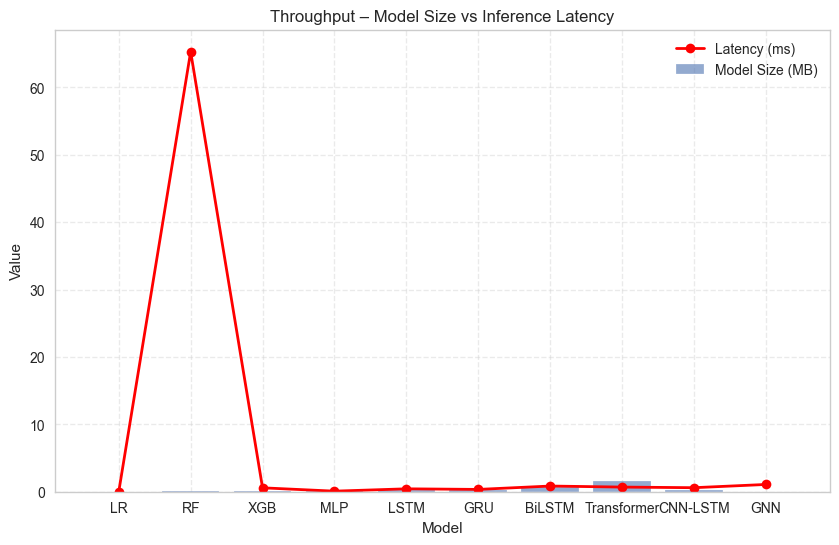

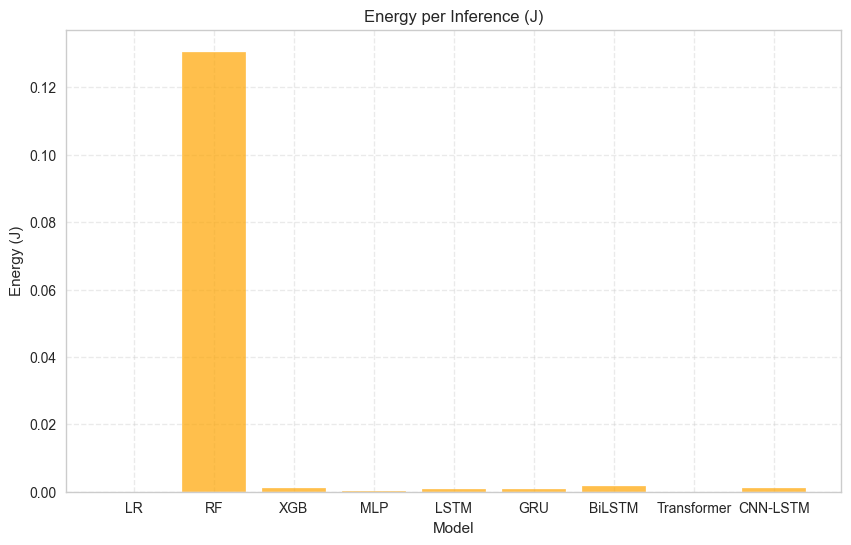

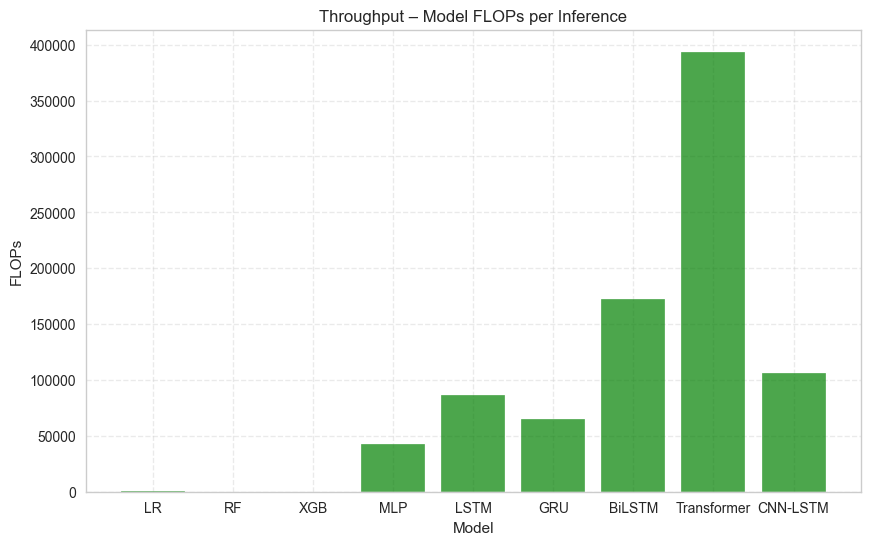

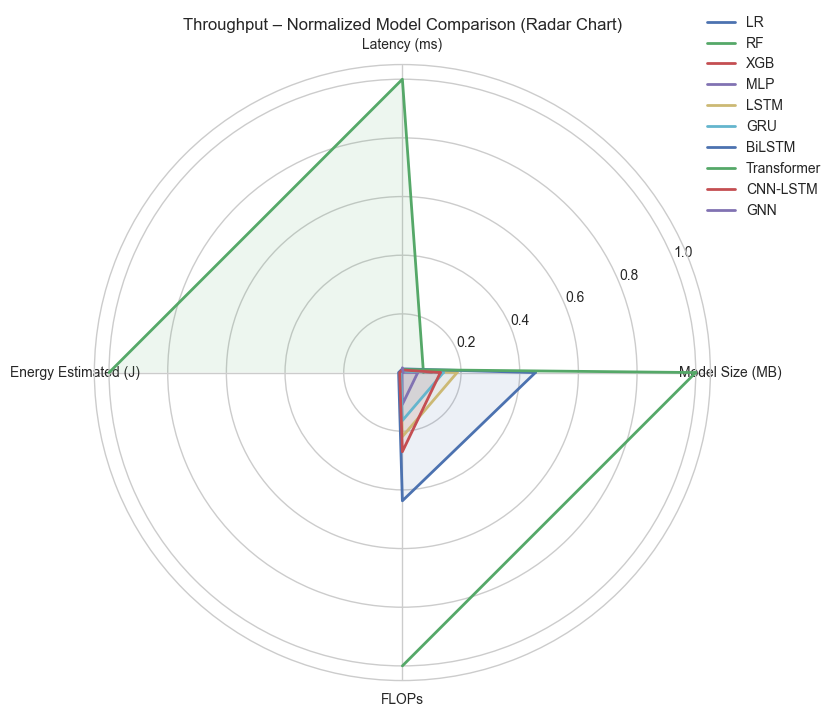

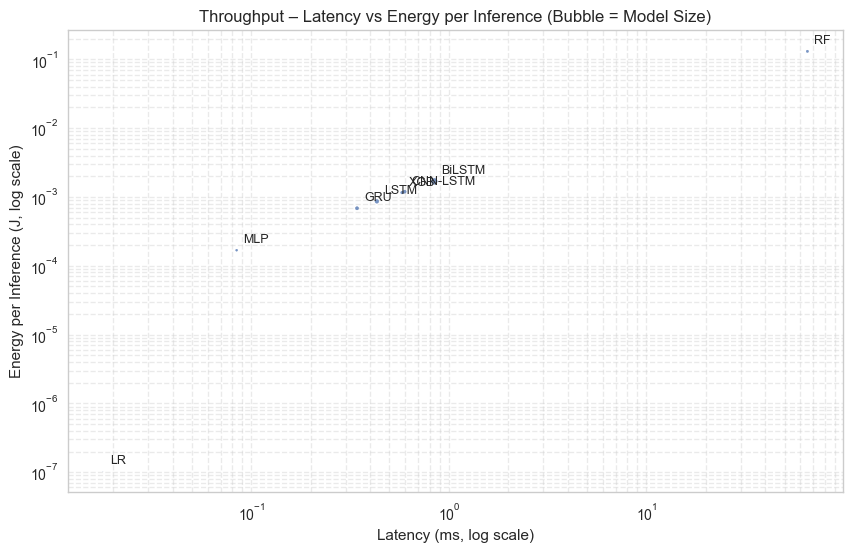


✔ All Throughput edge comparison plots generated successfully.


In [55]:
# Throughput plots
generate_edge_comparison_plots(metric="Throughput",showImage=True)

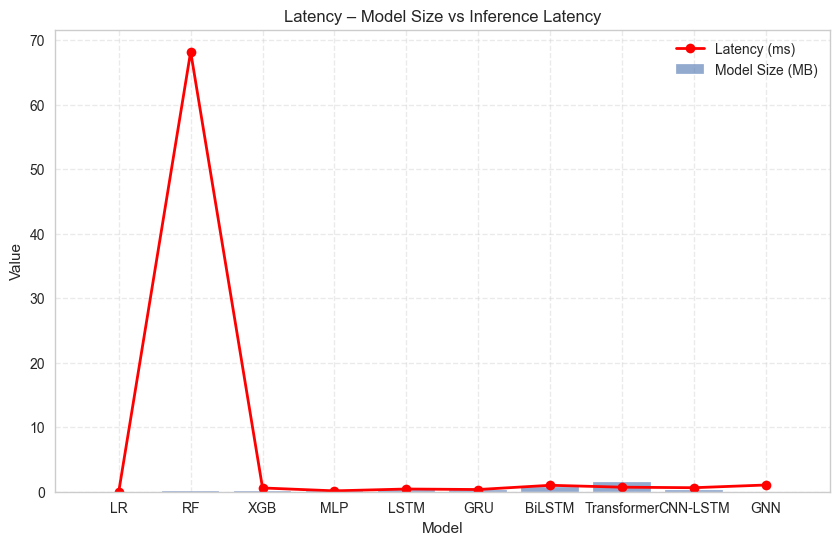

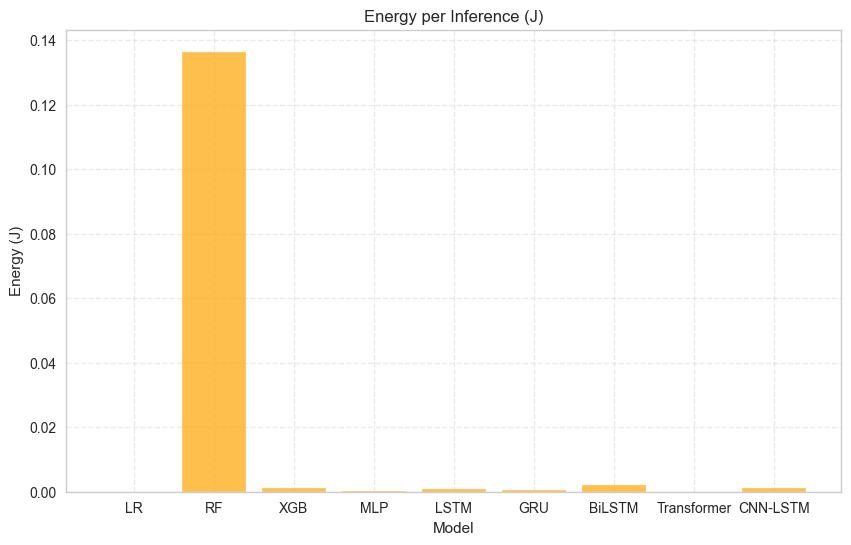

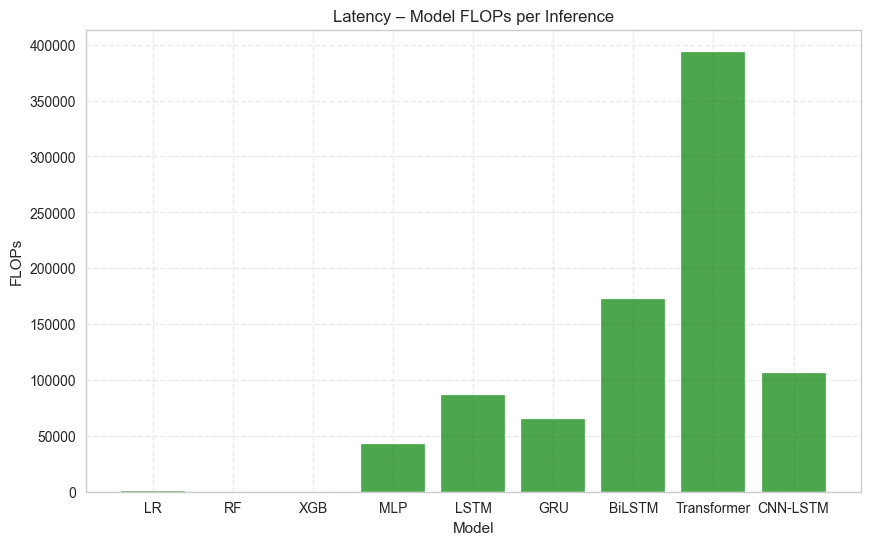

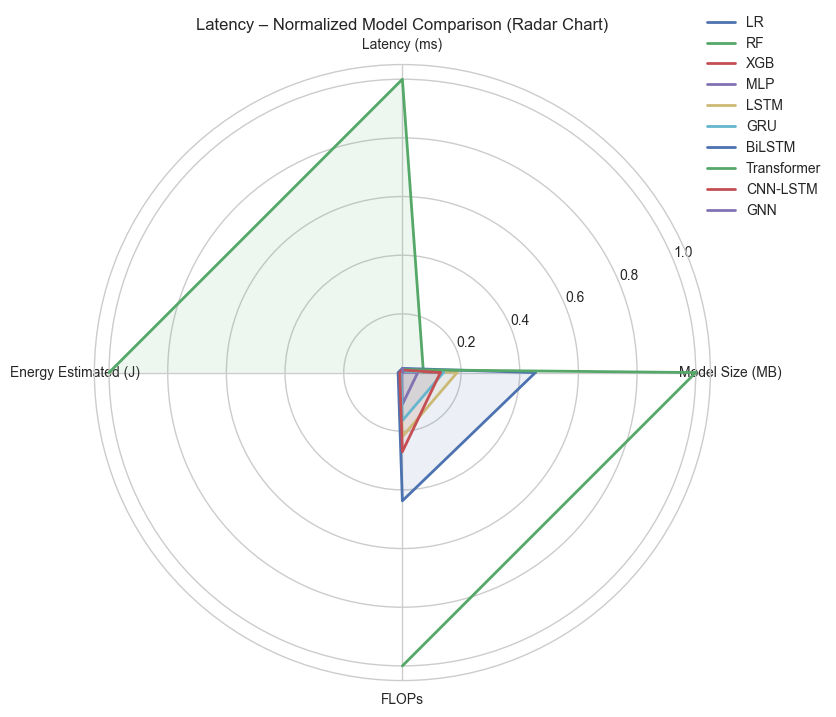

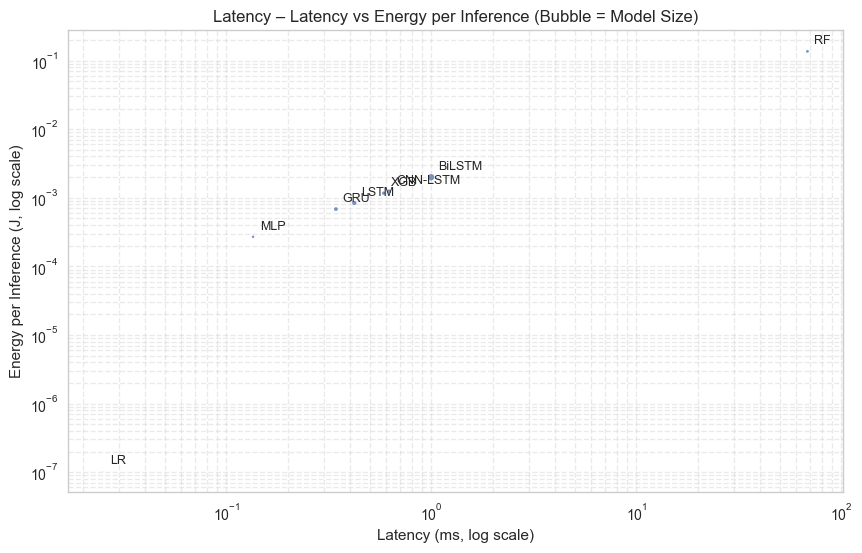


✔ All Latency edge comparison plots generated successfully.


In [56]:
generate_edge_comparison_plots(metric="Latency",showImage=True)


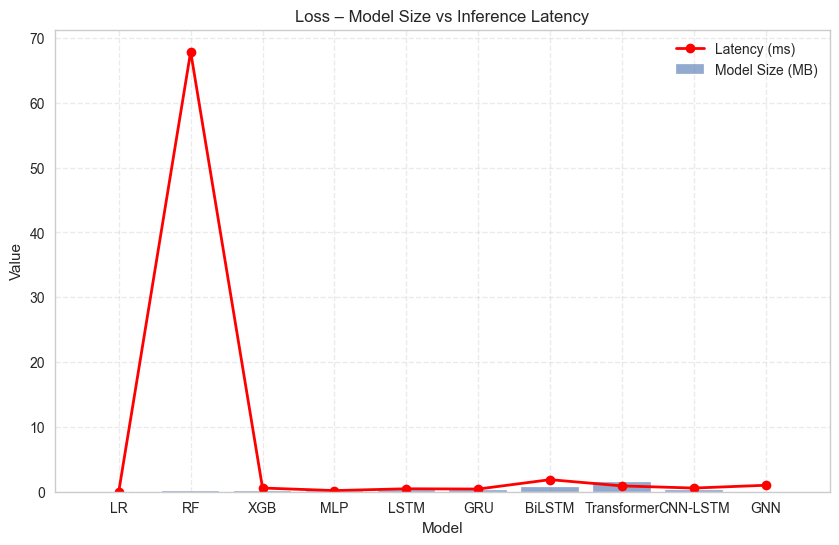

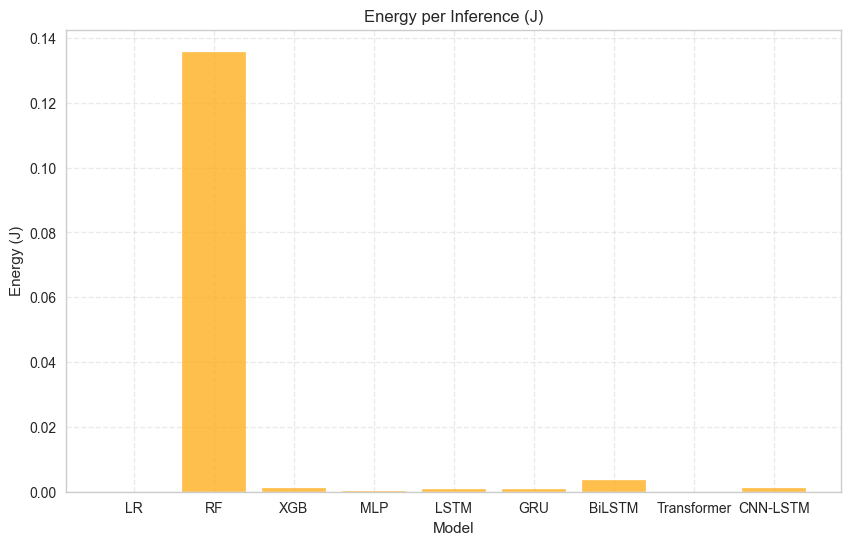

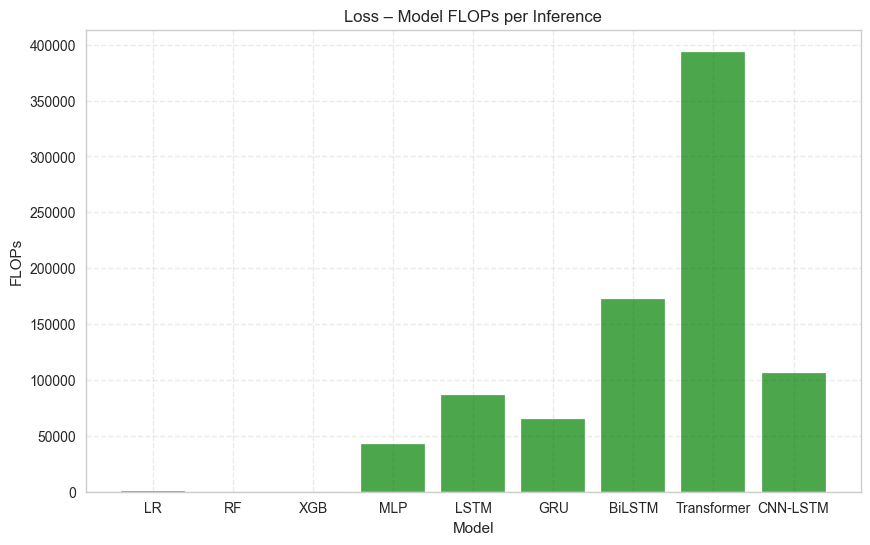

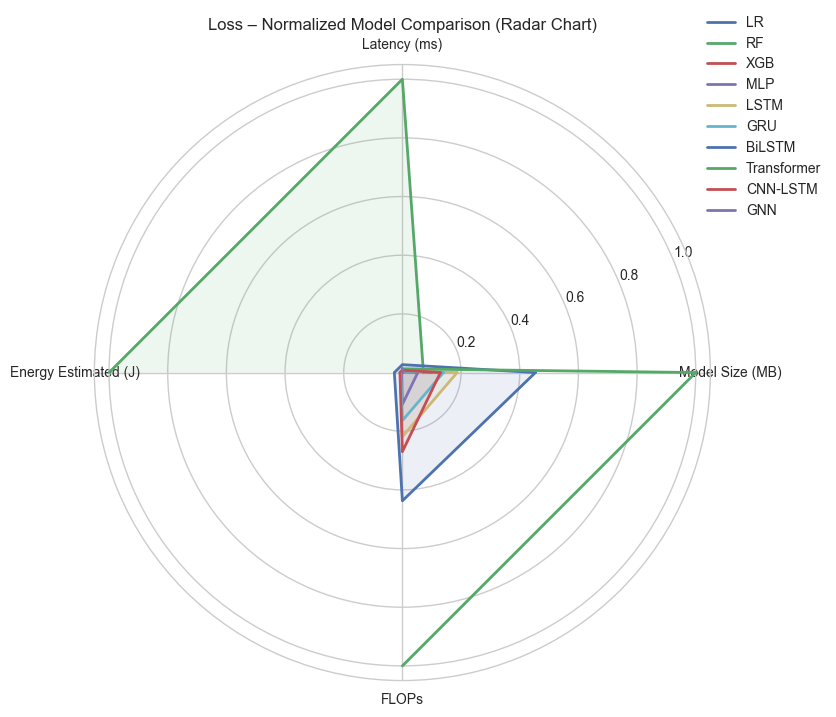

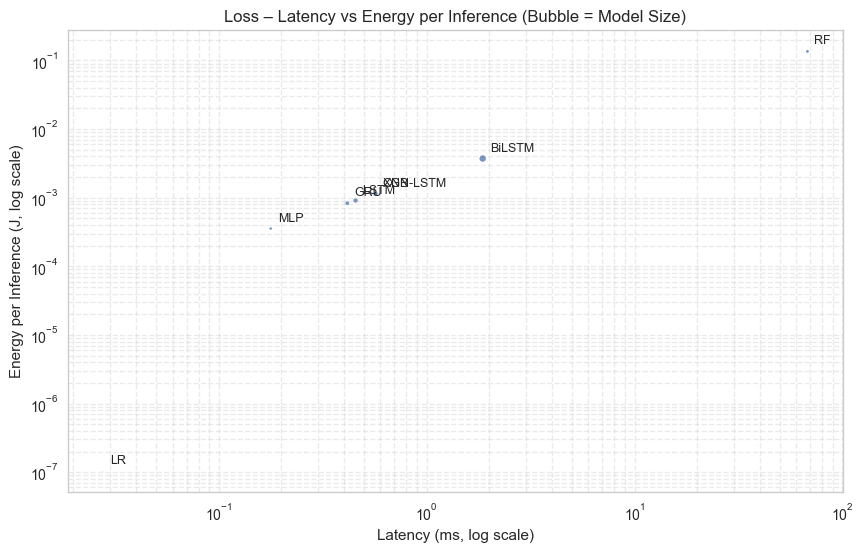


✔ All Loss edge comparison plots generated successfully.


In [57]:
generate_edge_comparison_plots(metric="Loss",showImage=True)

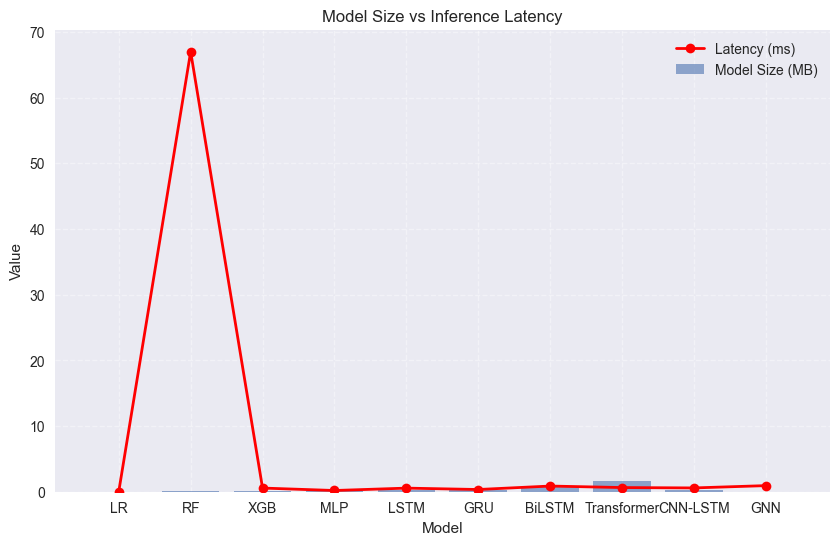

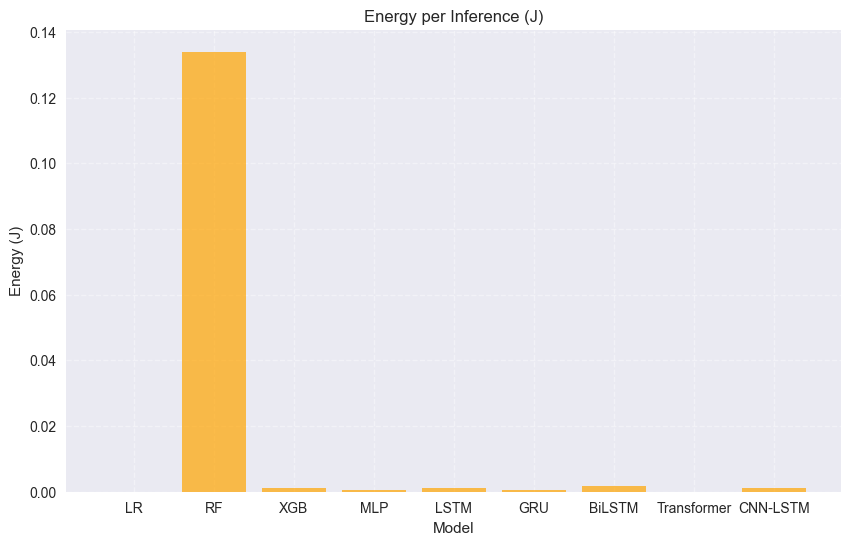

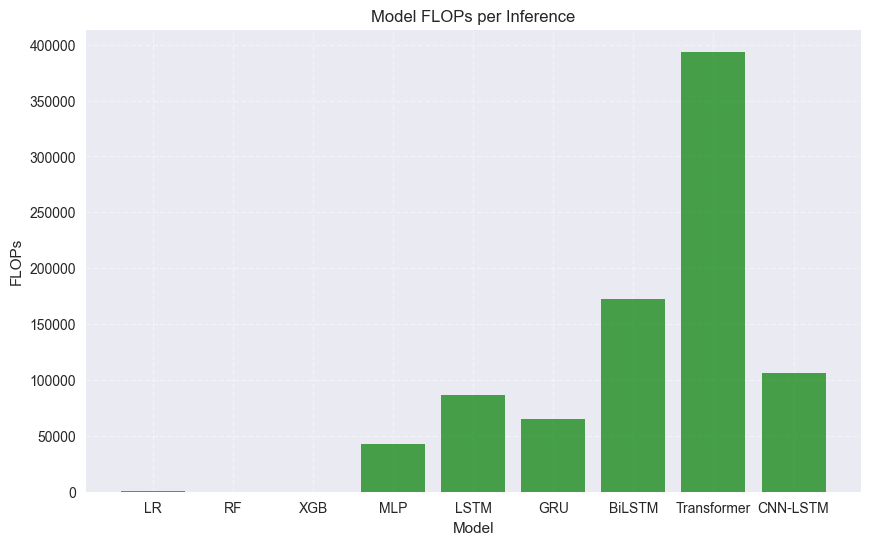

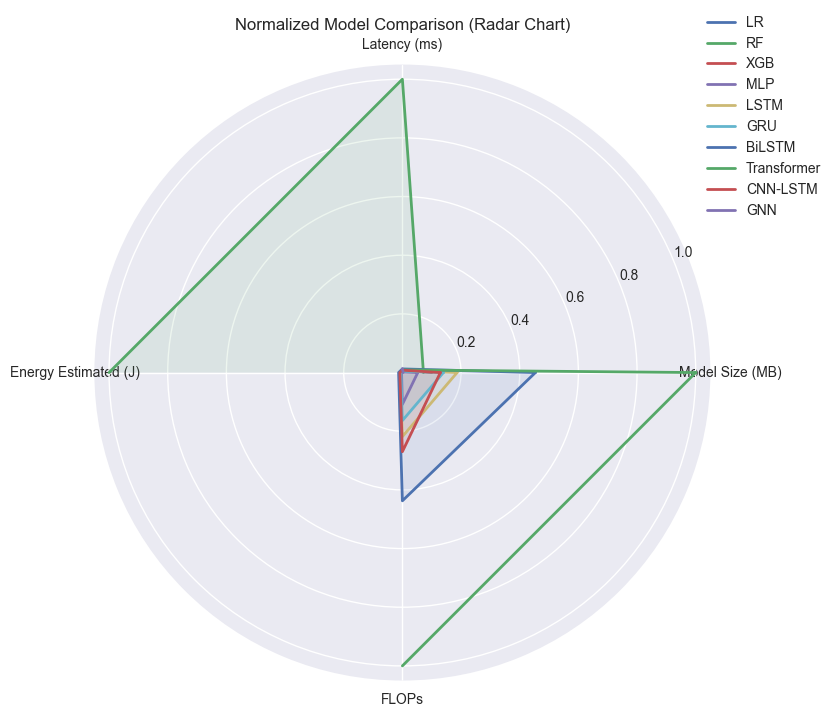

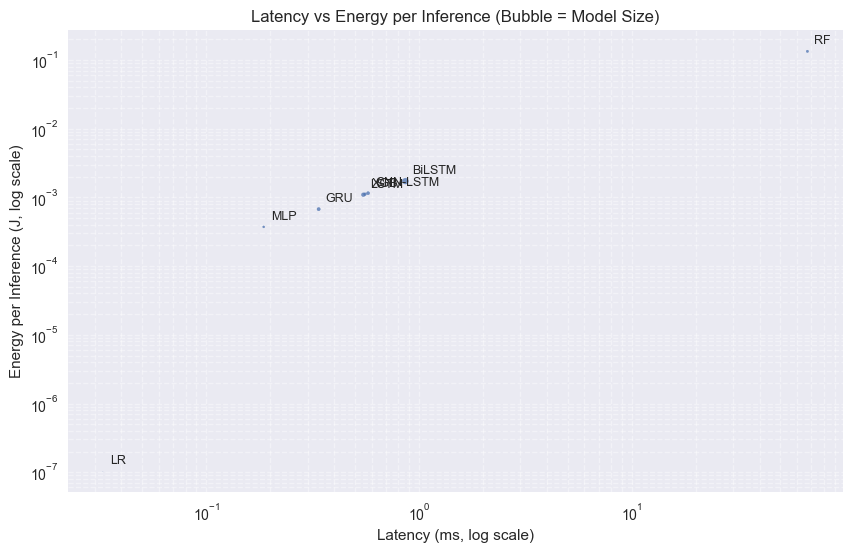


✔ All comparison plots generated successfully.


In [20]:
generate_edge_comparison_plots(showImage=True)